# Imports and load data

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/03_selected/selected_features_scaled.csv")

X = df.drop(columns=['target'])  

# Dendrogram

Agglomerative approach with ward  and complete linkage

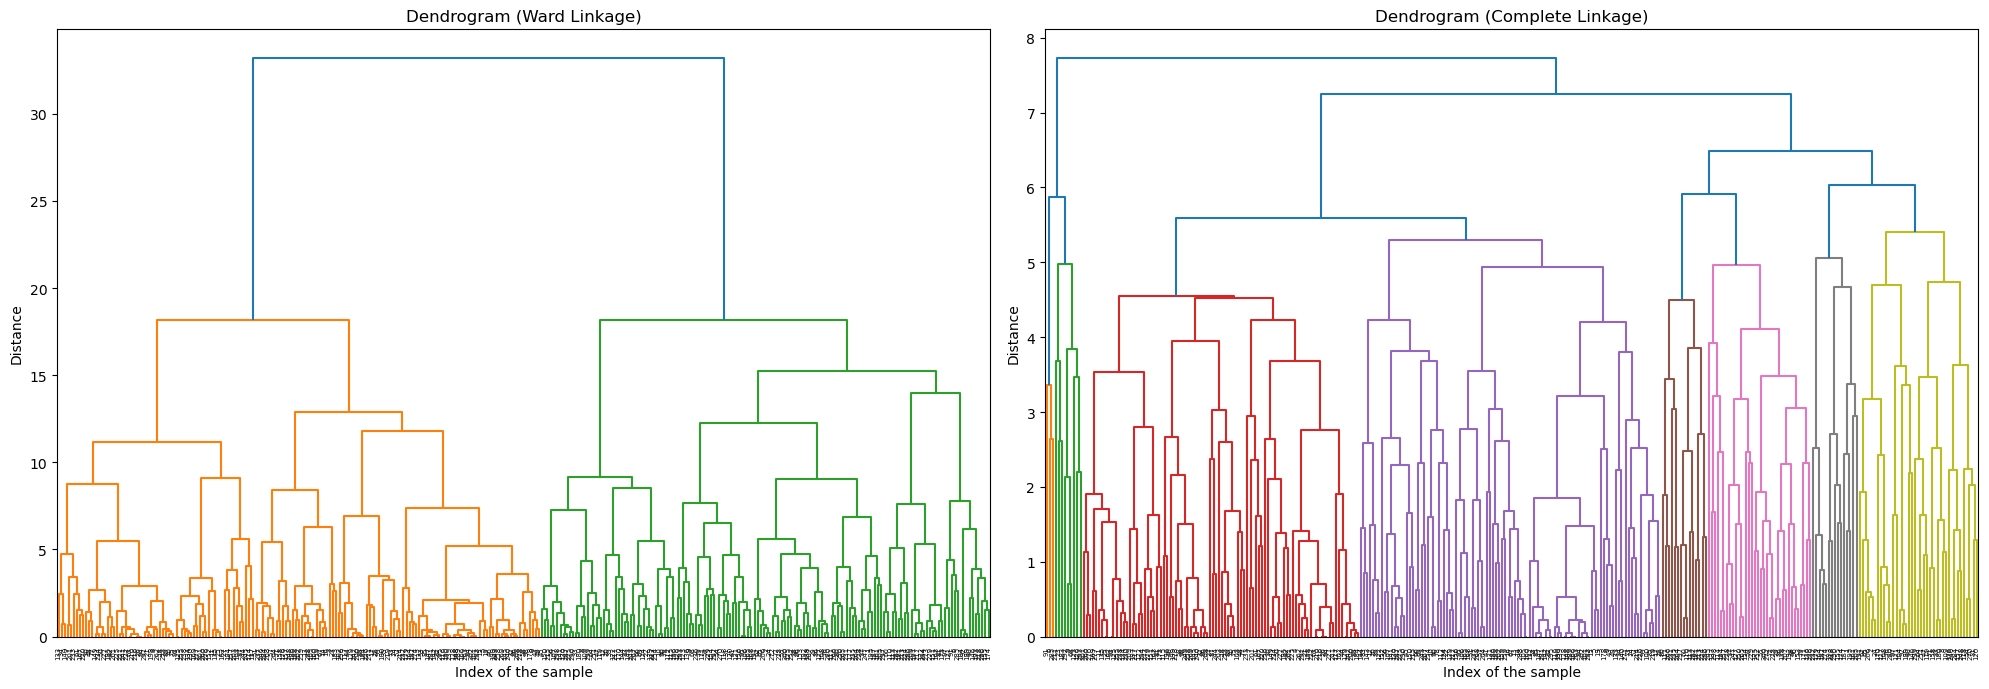

In [15]:
# Compute linkage matrix
Z_ward = linkage(X, method='ward')
Z_complete = linkage(X, method='complete')

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Ward dendrogram
dendrogram(Z_ward, ax=axes[0])
axes[0].set_title("Dendrogram (Ward Linkage)")
axes[0].set_xlabel("Index of the sample")
axes[0].set_ylabel("Distance")

# Complete dendrogram
dendrogram(Z_complete, ax=axes[1])
axes[1].set_title("Dendrogram (Complete Linkage)")
axes[1].set_xlabel("Index of the sample")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()

# Decision: number of clusters

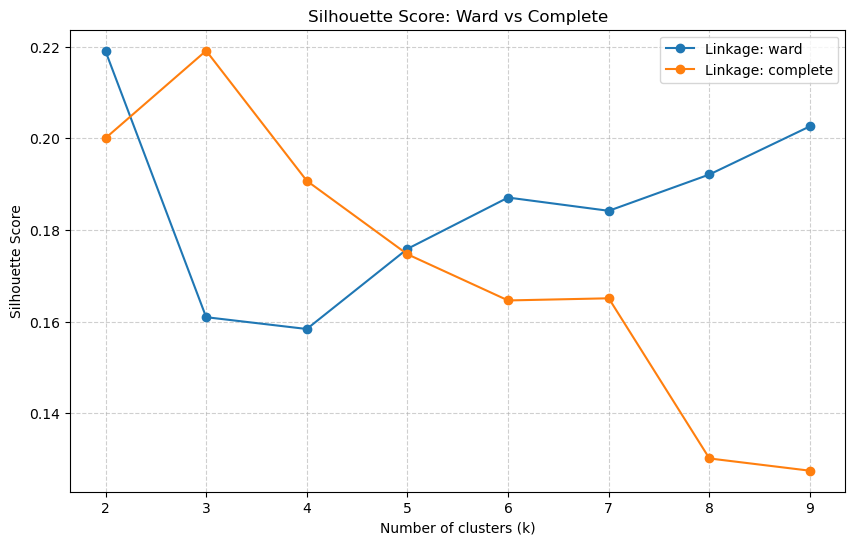

In [16]:
# Define ranges and type of linkages
k_values = range(2, 10)
linkages = ['ward', 'complete']
results = {}

# iterate in every linkage type
for link in linkages:
    scores = []
    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = model.fit_predict(X)
        
        score = silhouette_score(X, labels)
        scores.append(score)
    results[link] = scores

plt.figure(figsize=(10, 6))

for link, scores in results.items():
    plt.plot(k_values, scores, marker='o', label=f'Linkage: {link}')

plt.title("Silhouette Score: Ward vs Complete")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The silhouette scores are relatively low (<0.5), suggesting that the cluster structure is not strongly defined. 
With ward linkage the best silhouette score is for k = 2 and for complete linkage k = 3.

Looking the dendrograms and taking into account the binary target variable it is better to chose the ward linkage with k = 2. 

# Apply clustering

In [20]:
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(X)

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

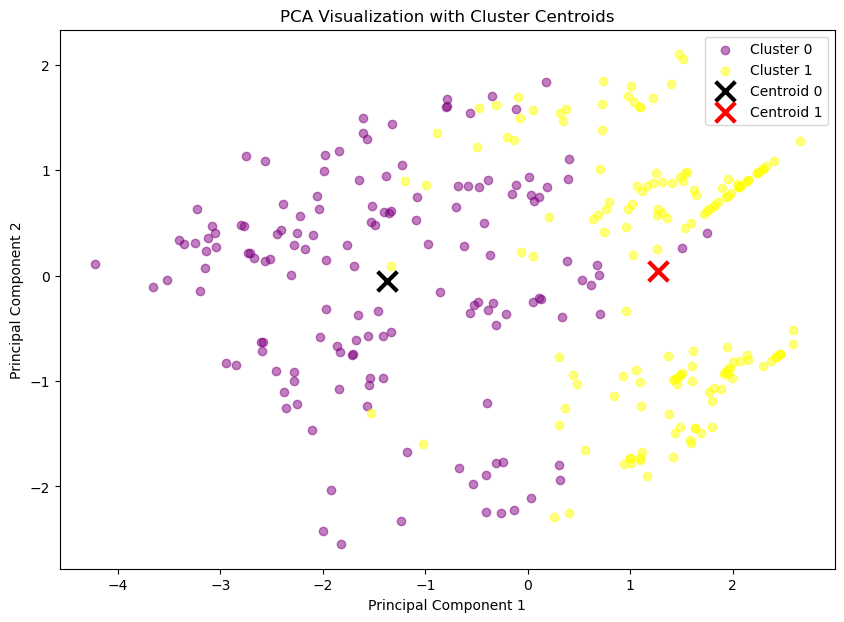

In [22]:
# 1. Compute the mean (centroid) of every cluster in PCA space
centroid0 = X_pca[labels == 0].mean(axis=0)
centroid1 = X_pca[labels == 1].mean(axis=0)

plt.figure(figsize=(10, 7))

# 2. Plot
plt.scatter(X_pca[labels == 0, 0], X_pca[labels == 0, 1], c='purple', label='Cluster 0', alpha=0.5)
plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], c='yellow', label='Cluster 1', alpha=0.5)

# 3. Plot centroids
plt.scatter(centroid0[0], centroid0[1], marker='x', s=200, linewidths=3, color='black', label='Centroid 0')
plt.scatter(centroid1[0], centroid1[1], marker='x', s=200, linewidths=3, color='red', label='Centroid 1')


plt.title("PCA Visualization with Cluster Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [32]:
#Show the means for every feature
df_clusters = pd.DataFrame(X)
df_clusters['cluster'] = labels

cluster_means = df_clusters.groupby('cluster').mean()
print(cluster_means)

          thalach   oldpeak        ca     sex_1      cp_4   exang_1   slope_2  \
cluster                                                                         
0       -0.491165  0.511814  0.294790  0.260439  0.515891  0.617685  0.680611   
1        0.456752 -0.475954 -0.274136 -0.242192 -0.479746 -0.574408 -0.632925   

         thal_7.0  
cluster            
0        0.430823  
1       -0.400638  


In [33]:
y_true = df['target']

# Confusion matrix

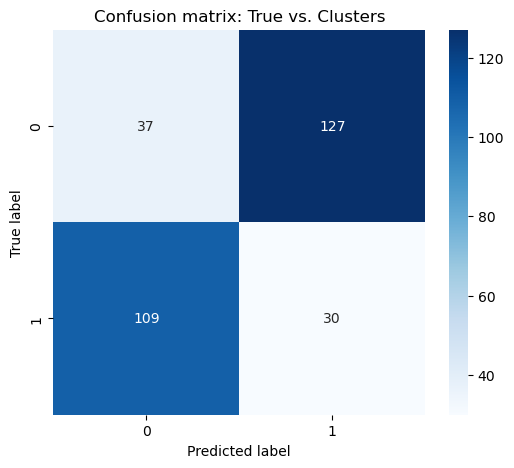

In [34]:
cm = confusion_matrix(y_true, labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix: True vs. Clusters")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# ARI score

In [35]:
ari = adjusted_rand_score(y_true, labels)
print(f"ARI score is: {ari:.4f}")

ARI score is: 0.3088
